In [1]:
!pip install -qr requirements.txt

DEPRECATION: Loading egg at /opt/homebrew/Cellar/tbb/2021.12.0/lib/python3.12/site-packages/TBB-0.2-py3.12-macosx-13.0-arm64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.1.1 -> 24.2
[notice] To update, run: /opt/homebrew/opt/python@3.12/bin/python3.12 -m pip install --upgrade pip


In [2]:
from scipy.io import mmread
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# node2vec
from node2vec import Node2Vec

# deep stuff
import torch
from torch_geometric.utils import from_networkx

/opt/homebrew/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from src.community_results import community_metrics, plot_communities, community_size_hist
from src.clustering import label_propagation, louvain, leiden, kmeans, optics
from src.DGIModel import DGIModel
from src.tune import tune

In [5]:
data_path = './data'

enron_path = f'{data_path}/email_enron_only.mtx'
univ_path = f'{data_path}/email_univ.edges'

In [6]:
# assume undirected graph
def read_adj_file(file, skip_rows: int = 0):
    lines = []
    with open(file, 'r') as f:
        lines = f.readlines()

    E = np.asarray([l.split() for l in lines[skip_rows:]]).astype(int)
    # index from 0
    E = E - E.min()

    adj = np.zeros((E.max() + 1, E.max() + 1))

    for (u, v) in E:
        adj[u, v] = 1
        adj[v, u] = 1

    return adj

# Load datasets

In [7]:
graphs = dict()

In [8]:
# not in standard mtx format
graphs['univ'] = nx.Graph(read_adj_file(univ_path))
graphs['univ'].number_of_nodes(), graphs['univ'].number_of_edges(), graphs['univ'].is_directed()

(1133, 5451, False)

In [9]:
graphs['enron'] = nx.Graph(mmread(enron_path).toarray())
graphs['enron'].number_of_nodes(), graphs['enron'].number_of_edges(), graphs['enron'].is_directed()

(143, 623, False)

In [10]:
graphs['karate'] = nx.karate_club_graph()
graphs['karate'] .number_of_nodes(), graphs['karate'] .number_of_edges(), graphs['karate'] .is_directed()

(34, 78, False)

# Select Dataset

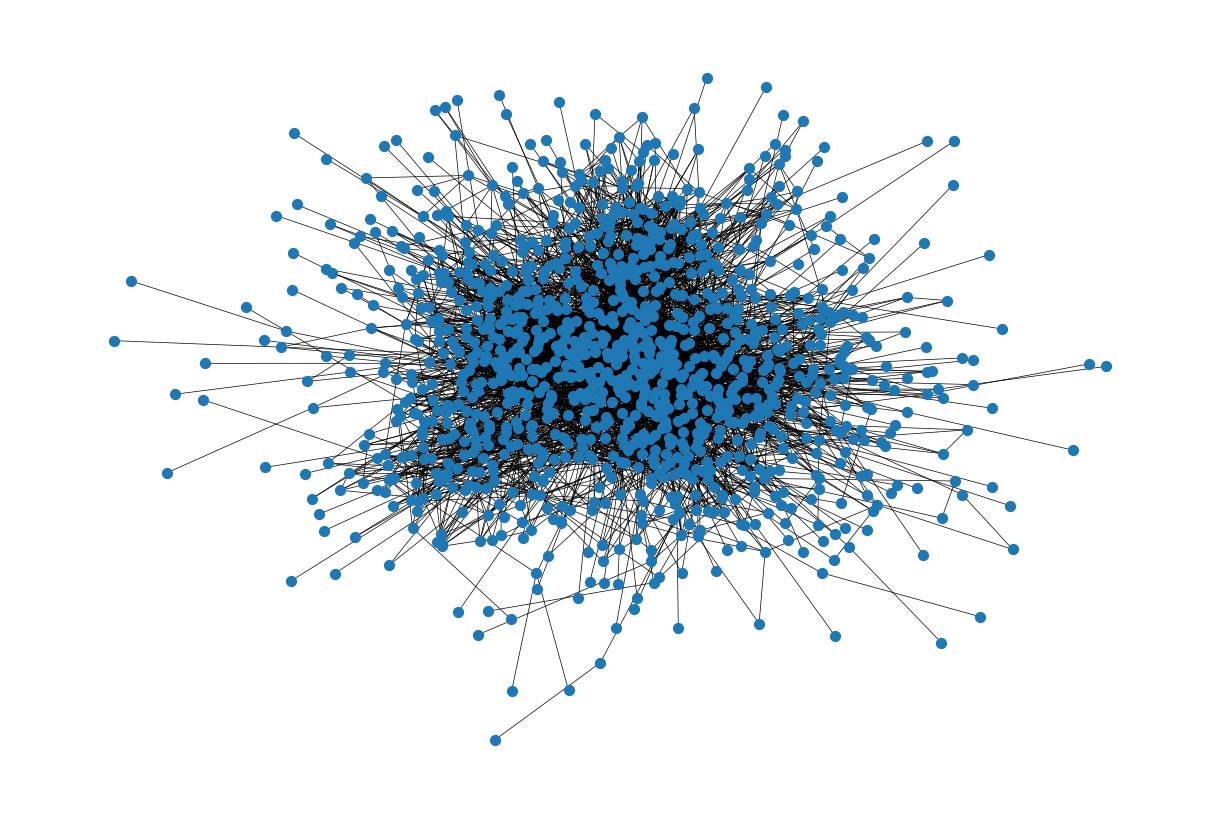

In [45]:
sel_graph = 'univ'
g = graphs[sel_graph]
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(g, k=0.1)  # 'k' controls the distance between nodes, lower values make edges shorter
nx.draw(g, pos, node_size=50, width=0.5)  # 'width' controls edge thickness

plt.show()

# Apply graph based clustering

## Label Propagation

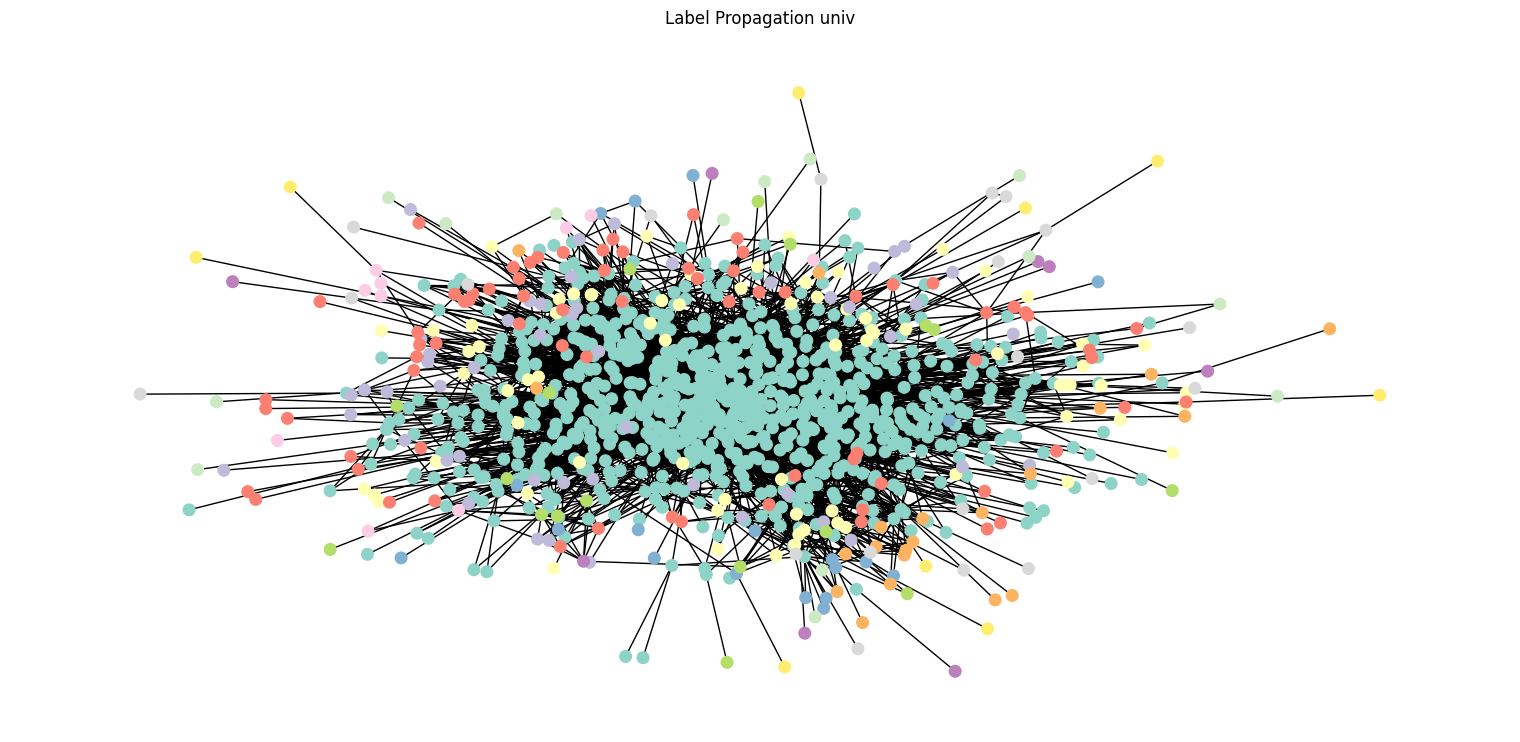

{'Number of Communities': 44,
 'Average Community Size': 25.75,
 'Modularity': 0.4633824482091431,
 'Average Cluster Coefficients': 0.22017608650411602,
 'Number of connected components': 1,
 'Coverage': 0.744083654375344,
 'Performance': 0.7598685749394178}

In [51]:
lp_labels = label_propagation(g)

plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}", plot_labels=False)

# Calculate metrics for LP
lp_metrics = community_metrics(g, lp_labels)
lp_metrics

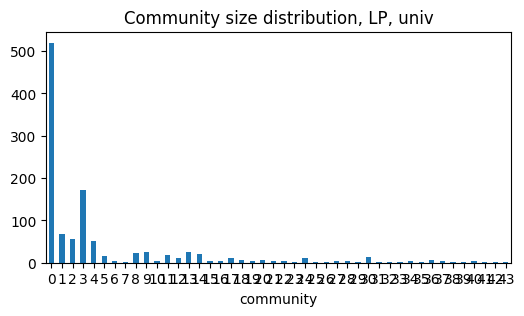

In [13]:
community_size_hist(lp_labels, title=f"Community size distribution, LP, {sel_graph}")

## Louvain

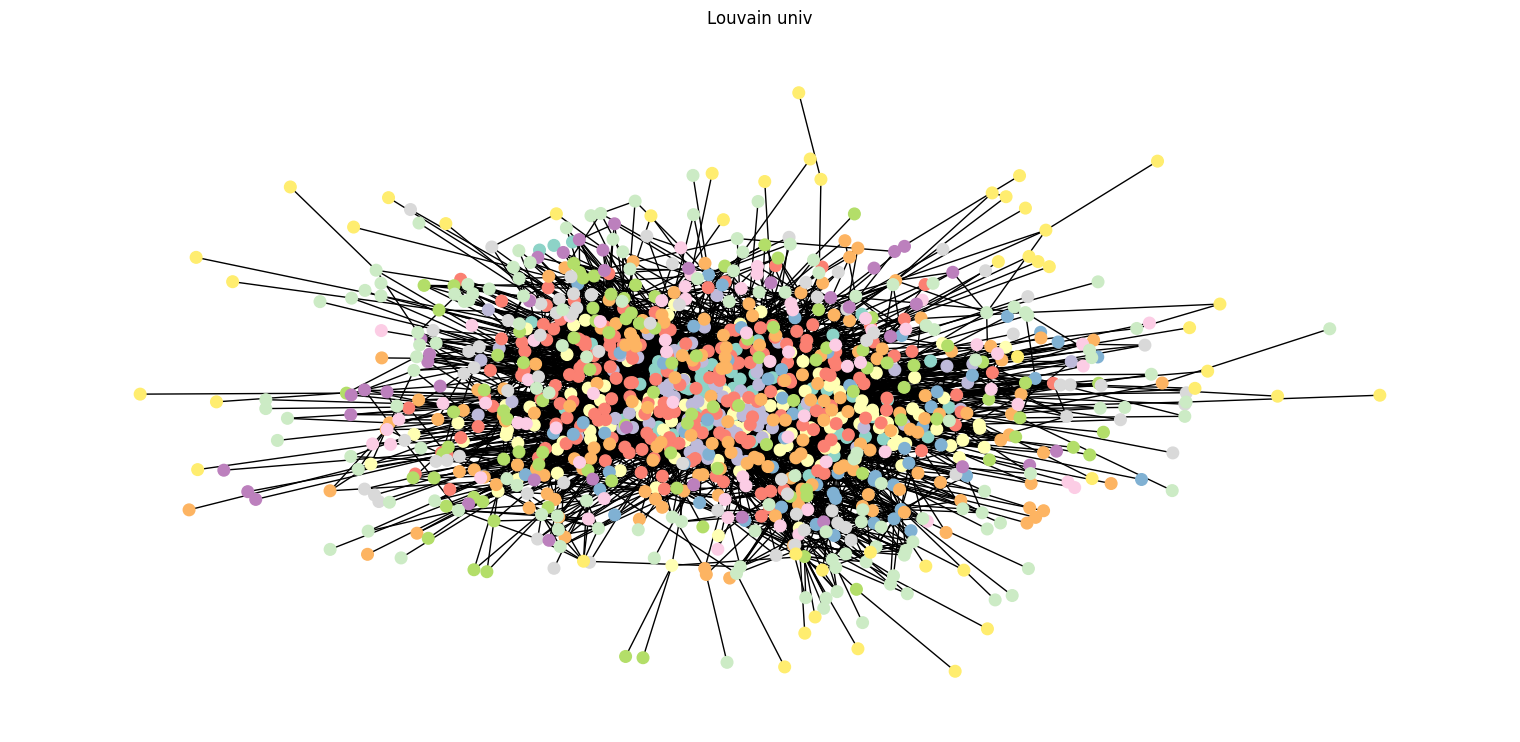

{'Number of Communities': 13,
 'Average Community Size': 87.15384615384616,
 'Modularity': 0.5613927870458182,
 'Average Cluster Coefficients': 0.22017608650411602,
 'Number of connected components': 1,
 'Coverage': 0.6789579893597505,
 'Performance': 0.9003583469259822}

In [52]:
lv_labels = louvain(g)

plot_communities(g, lv_labels, title=f"Louvain {sel_graph}", plot_labels=False)

# Calculate metrics for Louvain
lv_metrics = community_metrics(g, lv_labels)
lv_metrics

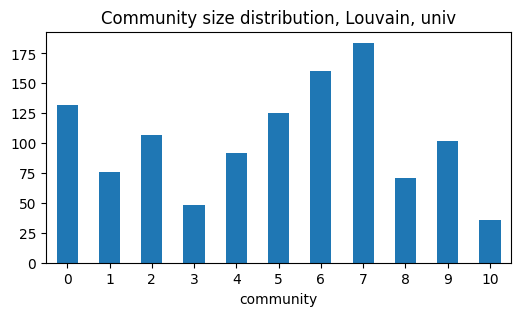

In [15]:
community_size_hist(lv_labels, title=f"Community size distribution, Louvain, {sel_graph}")

## Leiden

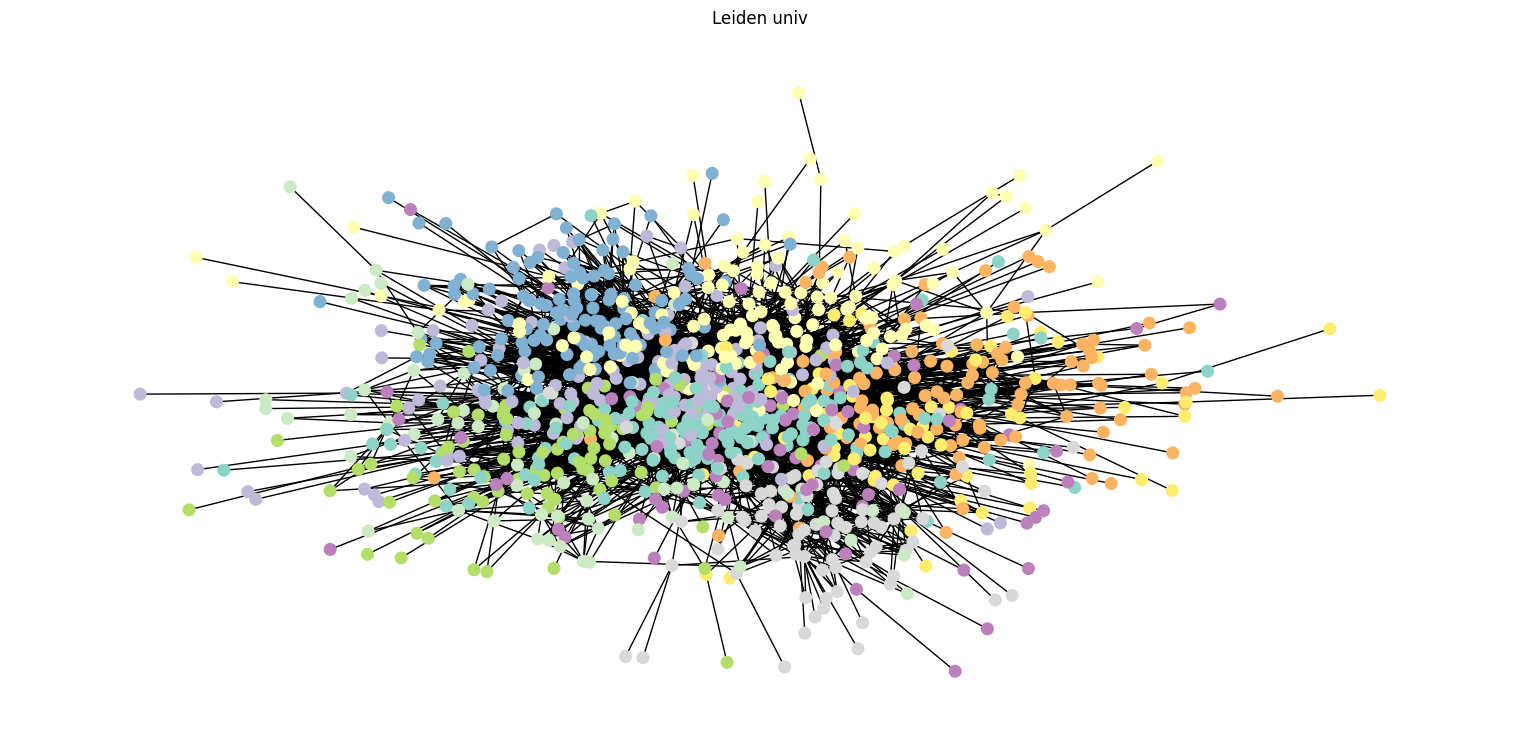

{'Number of Communities': 10,
 'Average Community Size': 113.3,
 'Modularity': 0.580485619939636,
 'Average Cluster Coefficients': 0.22017608650411602,
 'Number of connected components': 1,
 'Coverage': 0.699137772885709,
 'Performance': 0.8958657555693474}

In [53]:
ld_labels = leiden(g)

plot_communities(g, ld_labels, title=f"Leiden {sel_graph}", plot_labels=False)

# Calculate metrics for Leiden
ld_metrics = community_metrics(g, ld_labels)
ld_metrics

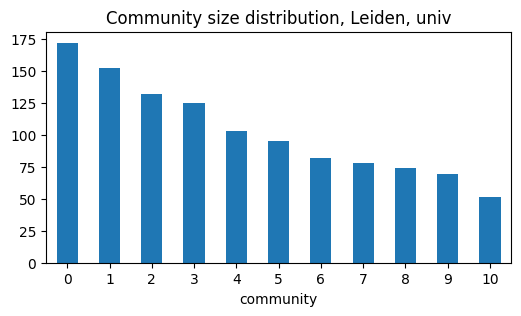

In [17]:
community_size_hist(ld_labels, title=f"Community size distribution, Leiden, {sel_graph}")

# node2vec

In [18]:
node2vec = Node2Vec(g, dimensions=32, walk_length=20, num_walks=100, workers=4) 

# Embed nodes
# Any keywords acceptable by gensim.Word2Vec can be passed, 
# `dimensions` and `workers` are automatically passed (from the Node2Vec constructor)
node2vec_model = node2vec.fit(window=10, min_count=1, batch_words=4)  

Generating walks (CPU: 4): 100%|██████████| 25/25 [00:01<00:00, 18.92it/s]


## Clustering using node2vec only

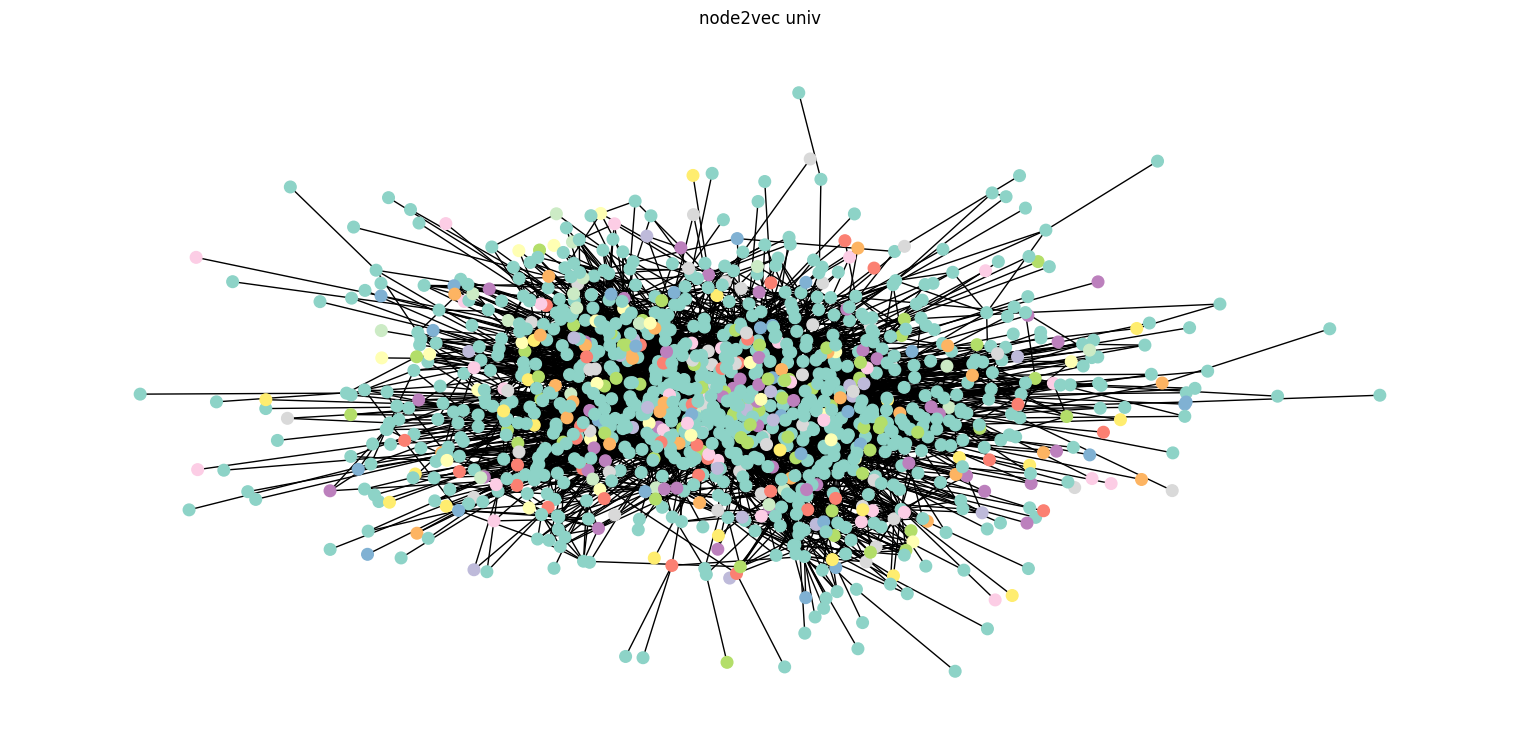

{'Number of Communities': 41,
 'Average Community Size': 27.634146341463413,
 'Modularity': -0.0015851938322374829,
 'Average Cluster Coefficients': 0.22017608650411602,
 'Number of connected components': 1,
 'Coverage': 0.43955237571087874,
 'Performance': 0.5667838285423794}

In [54]:
modularity, best_n, n2v_communities = optics(g, node2vec_model.wv.get_normed_vectors())

plot_communities(g, n2v_communities, title=f"node2vec {sel_graph}", plot_labels=False)
community_metrics(g, n2v_communities)

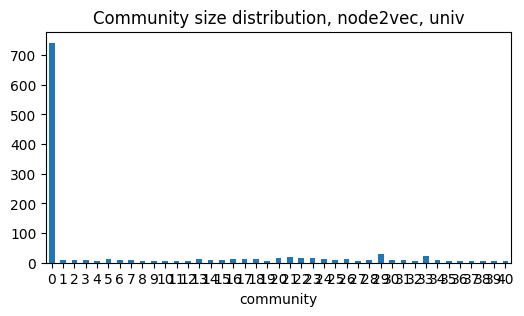

In [20]:
community_size_hist(n2v_communities, title=f"Community size distribution, node2vec, {sel_graph}")

# Apply GAT Embedding

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [22]:
# Convert networkx graph to PyTorch Geometric data object
data = from_networkx(g)

# Since the graph doesn't have node features, we use an identity matrix
data.x = torch.eye(g.number_of_nodes(), dtype=torch.float)

In [23]:
best_parameters_optuna = tune(data)
best_parameters_optuna

[I 2024-08-12 17:00:13,344] A new study created in memory with name: no-name-4d2dbf15-9a2c-4a2d-bdf4-3b976dcf3f15
[I 2024-08-12 17:00:20,427] Trial 0 finished with value: 0.09512399809096239 and parameters: {'hidden_channels': 36, 'out_channels': 27, 'heads': 2, 'learning_rate': 0.001108075958349191, 'dropout': 0.30108895262361385, 'weight_decay': 0.0008112333078665397}. Best is trial 0 with value: 0.09512399809096239.
[I 2024-08-12 17:00:33,992] Trial 1 finished with value: 0.1619566538344096 and parameters: {'hidden_channels': 48, 'out_channels': 17, 'heads': 8, 'learning_rate': 0.00027617724923474423, 'dropout': 0.7088772526380344, 'weight_decay': 2.9950841064371082e-05}. Best is trial 1 with value: 0.1619566538344096.
[I 2024-08-12 17:00:39,534] Trial 2 finished with value: 0.034540509179679546 and parameters: {'hidden_channels': 13, 'out_channels': 11, 'heads': 5, 'learning_rate': 0.007330896428713251, 'dropout': 0.2788754080906195, 'weight_decay': 0.0004973631307890179}. Best is 

In [24]:
best_parameters_optuna.best_value

0.23958287373431264

In [25]:
best_parameters = best_parameters_optuna.best_params

hidden_channels = best_parameters['hidden_channels']
out_channels = best_parameters['out_channels']
heads = best_parameters['heads']
dropout = best_parameters['dropout']
lr = best_parameters['learning_rate']
l2_reg = best_parameters['weight_decay']
epochs = 100
num_layers = 2

In [26]:
model = DGIModel(in_channels=data.num_features, hidden_channels=hidden_channels, out_channels=out_channels, num_layers=num_layers, heads=heads, dropout=dropout)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)

def train():
    model.train()
    optimizer.zero_grad()
    pos_z, neg_z, summary = model(data)
    loss = model.dgi.loss(pos_z, neg_z, summary)
    loss.backward()
    optimizer.step()
    return loss.item()

# Training the model
for epoch in range(epochs):
    loss = train()
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss}')

Epoch 0, Loss: 1.3872088193893433
Epoch 10, Loss: 1.386044979095459
Epoch 20, Loss: 1.3782122135162354
Epoch 30, Loss: 1.3786029815673828
Epoch 40, Loss: 1.3717880249023438
Epoch 50, Loss: 1.371284008026123
Epoch 60, Loss: 1.3649728298187256
Epoch 70, Loss: 1.365856409072876
Epoch 80, Loss: 1.3591806888580322
Epoch 90, Loss: 1.3462016582489014


In [27]:
# Extract node embeddings
model.eval()
with torch.no_grad():
    node_embeddings = model.encoder(data.x, data.edge_index)

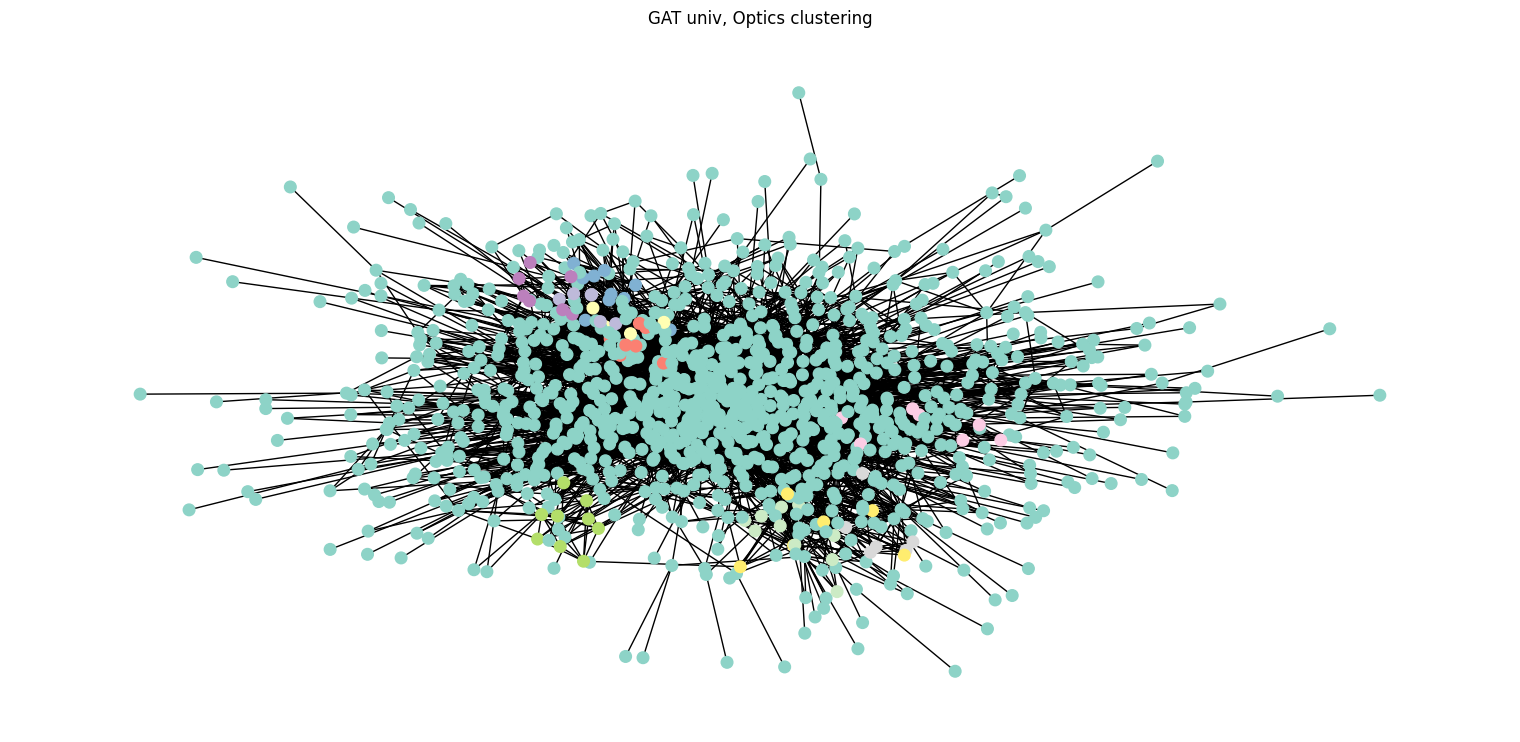

{'Number of Communities': 11,
 'Average Community Size': 103.0,
 'Modularity': 0.06419207952667559,
 'Average Cluster Coefficients': 0.22017608650411602,
 'Number of connected components': 1,
 'Coverage': 0.9128600256833609,
 'Performance': 0.13140166979063683}

In [55]:
# optics clustering
modularity, best_n, gat_communities = optics(g, node_embeddings.detach().cpu().numpy())

plot_communities(g, gat_communities, title=f"GAT {sel_graph}, Optics clustering", plot_labels=False)
community_metrics(g, gat_communities)

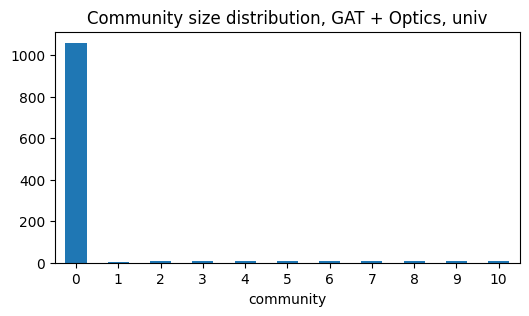

In [29]:
community_size_hist(gat_communities, title=f"Community size distribution, GAT + Optics, {sel_graph}")

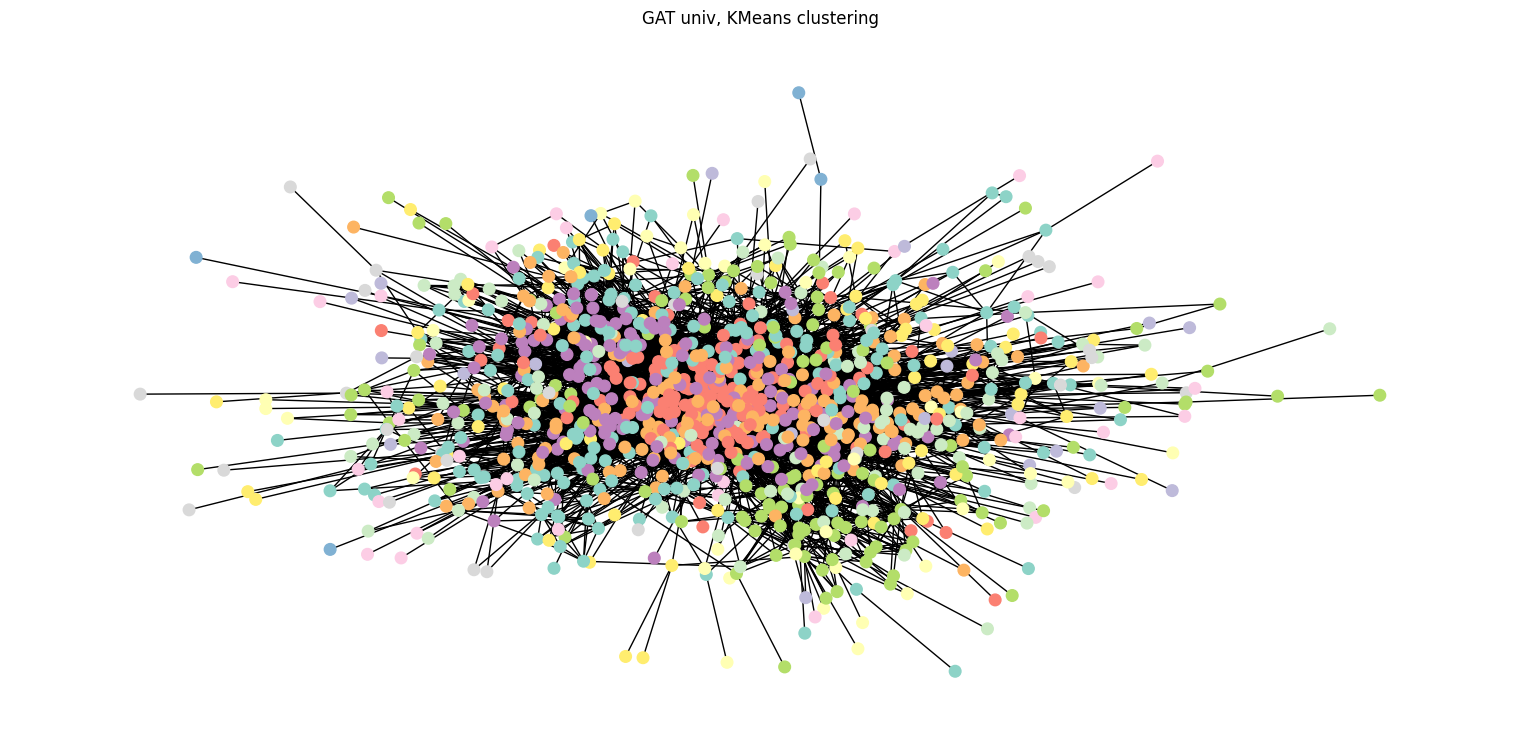

{'Number of Communities': 15,
 'Average Community Size': 75.53333333333333,
 'Modularity': 0.290359726912446,
 'Average Cluster Coefficients': 0.22017608650411602,
 'Number of connected components': 1,
 'Coverage': 0.45918180150431115,
 'Performance': 0.8954681121136231}

In [56]:
# kmeans clustering
modularity, best_n, gat_communities = kmeans(g, node_embeddings.detach().cpu().numpy(), max_num_clusters=20)

plot_communities(g, gat_communities, title=f"GAT {sel_graph}, KMeans clustering", plot_labels=False)
community_metrics(g, gat_communities)

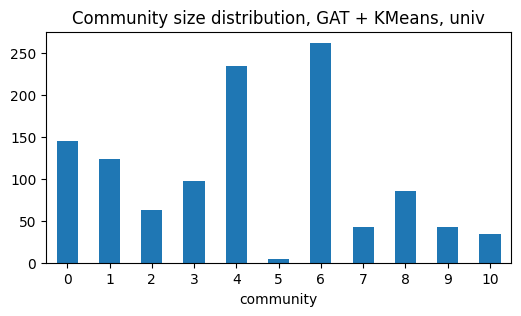

In [31]:
community_size_hist(gat_communities, title=f"Community size distribution, GAT + KMeans, {sel_graph}")

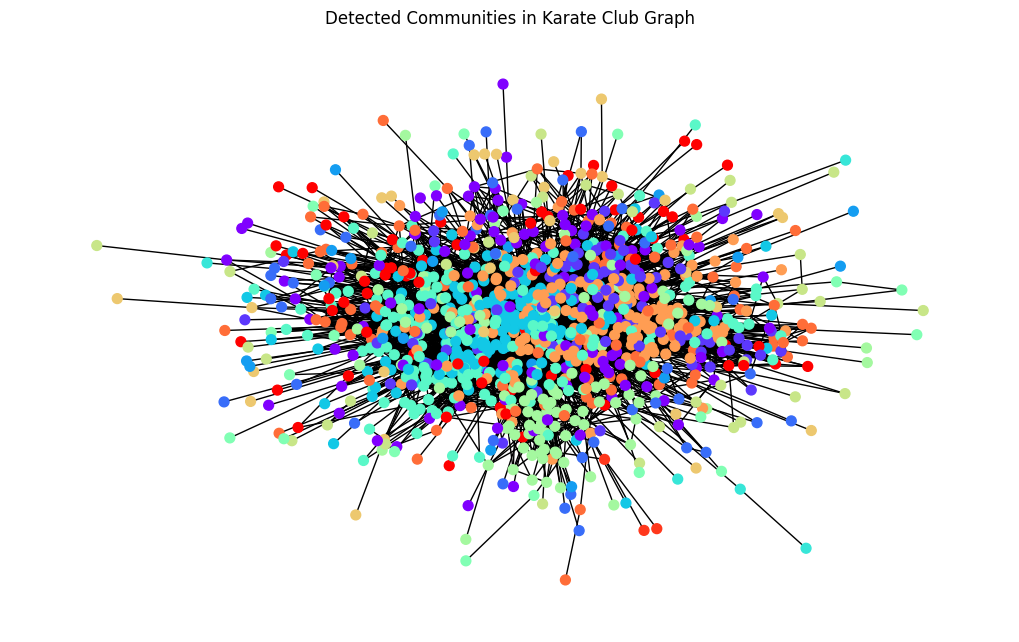

In [49]:
# Plotting the communities
plt.figure(figsize=(10, 6))
nx.draw(g, node_color=list(gat_communities.values()), cmap=plt.cm.rainbow, node_size=50)
plt.title("Detected Communities in Karate Club Graph")
plt.show()